In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r'D:\solar-performance-monitoring\data\processed\cleaned_data\final_data_forecasting.csv')
cols = [
    "A0-Grid over voltage",
    "A1-Grid under voltage",
    "A2-Grid absent",
    "A3-Grid over frequency",
    "A4-Grid under frequency",
    "A6-Grid abnormal"
]
df[cols]=df[cols].astype('int')
df.drop(columns=['E-Today(KWH)'], inplace=True)

df

,date,A0-Grid over voltage,A1-Grid under voltage,A2-Grid absent,A3-Grid over frequency,A4-Grid under frequency,A6-Grid abnormal
0,2024-11-16,0,0,0,0,0,0
1,2024-11-17,0,0,0,0,0,0
2,2024-11-18,0,0,0,0,0,0
3,2024-11-19,0,1,1,0,1,0
4,2024-11-20,0,0,0,0,0,0
...,...,...,...,...,...,...,...
502,2026-04-01,0,2,2,2,2,0
503,2026-04-02,0,0,0,0,0,0
504,2026-04-03,2,3,2,2,2,1
505,2026-04-04,0,4,0,0,0,0


In [2]:
df.duplicated().sum()

np.int64(1)

In [3]:
df.replace(0, np.nan).count()

date                       507
A0-Grid over voltage       142
A1-Grid under voltage      120
A2-Grid absent             111
A3-Grid over frequency      78
A4-Grid under frequency    112
A6-Grid abnormal             6
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   date                     507 non-null    object
 1   A0-Grid over voltage     507 non-null    int64 
 2   A1-Grid under voltage    507 non-null    int64 
 3   A2-Grid absent           507 non-null    int64 
 4   A3-Grid over frequency   507 non-null    int64 
 5   A4-Grid under frequency  507 non-null    int64 
 6   A6-Grid abnormal         507 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 27.9+ KB


In [5]:
df.describe()

,A0-Grid over voltage,A1-Grid under voltage,A2-Grid absent,A3-Grid over frequency,A4-Grid under frequency,A6-Grid abnormal
count,507.000000,507.000000,507.000000,507.000000,507.000000,507.000000
mean,1.278107,0.739645,0.771203,0.374753,0.688363,0.031558
std,3.299834,1.774675,2.173984,1.033813,1.748382,0.337085
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,50.000000,16.000000,22.000000,10.000000,16.000000,6.000000


In [6]:
# columns
cols = [
    "A0-Grid over voltage",
    "A1-Grid under voltage",
    "A2-Grid absent",
    "A3-Grid over frequency",
    "A4-Grid under frequency",
    "A6-Grid abnormal"
]

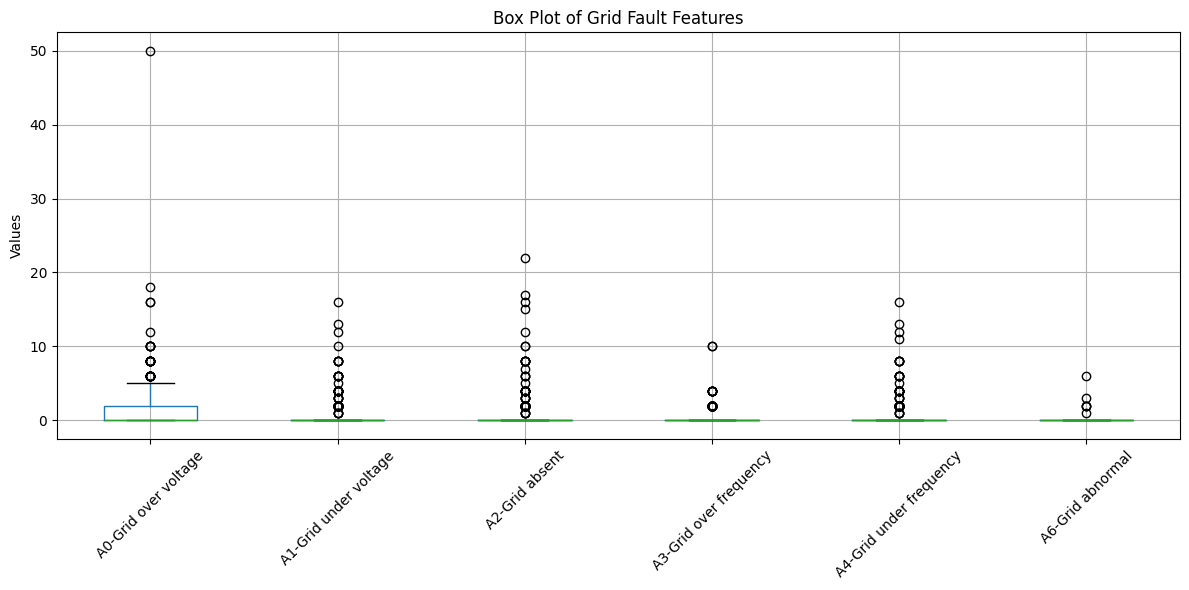

In [7]:
# assuming your dataframe is df
data = df

# create figure
plt.figure(figsize=(12, 6))

# boxplot
data.boxplot()

plt.title("Box Plot of Grid Fault Features")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.tight_layout()

plt.show()

In [8]:
df["total_error"] = df[cols].sum(axis=1)
df.drop(columns=cols, inplace=True)

In [9]:
df

,date,total_error
0,2024-11-16,0
1,2024-11-17,0
2,2024-11-18,0
3,2024-11-19,3
4,2024-11-20,0
...,...,...
502,2026-04-01,8
503,2026-04-02,0
504,2026-04-03,12
505,2026-04-04,4


Feature for Errors

In [11]:

df['month'] = df['date'].dt.month
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag1'] = df['total_error'].shift(1)
df['lag2'] = df['total_error'].shift(2)
df['roll_mean_3'] = df['total_error'].rolling(3).mean()
df['roll_mean_7'] = df['total_error'].rolling(7).mean()
df['diff1'] = df['total_error'].diff(1)
df['diff7'] = df['total_error'].diff(7)
df['roll_max_7'] = df['total_error'].rolling(7).max()
df['roll_min_7'] = df['total_error'].rolling(7).min()
df['lag1_roll7'] = df['lag1'] * df['roll_mean_7']
df = df.dropna()

df

,date,total_error,month,month_cos,lag1,lag2,roll_mean_3,roll_mean_7,diff1,diff7,roll_max_7,roll_min_7,lag1_roll7
7,2024-11-23,8,11,0.866025,0.0,0.0,2.666667,1.571429,8.0,8.0,8.0,0.0,0.000000
8,2024-11-24,0,11,0.866025,8.0,0.0,2.666667,1.571429,-8.0,0.0,8.0,0.0,12.571429
9,2024-11-25,0,11,0.866025,0.0,8.0,2.666667,1.571429,0.0,0.0,8.0,0.0,0.000000
10,2024-11-26,8,11,0.866025,0.0,0.0,2.666667,2.285714,8.0,5.0,8.0,0.0,0.000000
11,2024-11-27,6,11,0.866025,8.0,0.0,4.666667,3.142857,-2.0,6.0,8.0,0.0,25.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,2026-04-01,8,4,-0.500000,30.0,6.0,14.666667,6.285714,-22.0,8.0,30.0,0.0,188.571429
503,2026-04-02,0,4,-0.500000,8.0,30.0,12.666667,6.285714,-8.0,0.0,30.0,0.0,50.285714
504,2026-04-03,12,4,-0.500000,0.0,8.0,6.666667,8.000000,12.0,12.0,30.0,0.0,0.000000
505,2026-04-04,4,4,-0.500000,12.0,0.0,5.333333,8.571429,-8.0,4.0,30.0,0.0,102.857143


In [16]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

X_train = train.drop(['total_error','date'], axis=1)
y_train = train['total_error']

X_test = test.drop(['total_error','date'], axis=1)
y_test = test['total_error']

# XGBOOST

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,min_samples_split=5,
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
# Get importance
rf_importance = rf_model.feature_importances_

# Create dataframe
rf_feat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

print(rf_feat)

        Feature  Importance
7         diff7    0.746257
6         diff1    0.153540
4   roll_mean_3    0.050653
8    roll_max_7    0.015178
10   lag1_roll7    0.012045
2          lag1    0.006687
5   roll_mean_7    0.006120
3          lag2    0.004670
9    roll_min_7    0.002649
0         month    0.001390
1     month_cos    0.000809


# RANDOM FOREST

In [23]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_importance = xgb_model.feature_importances_

xgb_feat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending=False)

print(xgb_feat)

        Feature  Importance
7         diff7    0.726550
4   roll_mean_3    0.109255
9    roll_min_7    0.049955
6         diff1    0.048950
3          lag2    0.026081
8    roll_max_7    0.015006
10   lag1_roll7    0.012479
2          lag1    0.006716
5   roll_mean_7    0.002712
1     month_cos    0.001700
0         month    0.000597


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n{name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")



Random Forest Performance:
RMSE: 1.27
MAE: 0.56
R2: 0.95
MAPE: 17.12%

XGBoost Performance:
RMSE: 1.04
MAE: 0.49
R2: 0.97
MAPE: 16.57%
